# 07. 클러스터 구조 시각화 (블록 덴드로그램)

04에서 HDBSCAN으로 도출한 5개 클러스터의 내부 구조와 클러스터 간 관계를 계층적 덴드로그램으로 시각화합니다.

**방법:**
- 노이즈(-1) 제거 후, 클러스터별 비율에 맞게 샘플링
- 클러스터 간 순서: centroid 간 HAC(Average + Cosine)로 결정
- 클러스터 내부: 개별 HAC 덴드로그램을 블록별로 나란히 배치

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# =========================
# Settings
# =========================
PICKLE_PATH = 'df_labels.pkl'
LABEL_COL    = 'cluster_1400_7'
VECTOR_COL   = 'vector'

TOTAL_SAMPLES = 10_000
MAX_LEAVES    = 3_000
RANDOM_SEED   = 42
METRIC        = 'cosine'
METHOD        = 'average'
FIGSIZE       = (16, 8)
GAP           = 20.0

# =========================
# 1) Load data and filter out -1
# =========================
df_labels = pd.read_pickle(PICKLE_PATH)
mask = df_labels[LABEL_COL] != -1
df_labels = df_labels[mask]

Z_all   = np.vstack(df_labels[VECTOR_COL].values)
lbl_all = df_labels[LABEL_COL].values

# =========================
# 2) Proportionate sampling
# =========================
rng = np.random.default_rng(RANDOM_SEED)
uniq, cnts = np.unique(lbl_all, return_counts=True)
total_cnt  = cnts.sum()
take_per = {c: int(np.round(TOTAL_SAMPLES * (n / total_cnt))) for c, n in zip(uniq, cnts)}
allocated = sum(take_per.values())
remainder = TOTAL_SAMPLES - allocated
order_by_size = [c for c, _ in sorted(zip(uniq, cnts), key=lambda x: -x[1])]
i = 0
while remainder != 0 and order_by_size:
    c = order_by_size[i % len(order_by_size)]
    cap = (lbl_all == c).sum()
    if remainder > 0 and take_per[c] < cap:
        take_per[c] += 1
        remainder -= 1
    elif remainder < 0 and take_per[c] > 1:
        take_per[c] -= 1
        remainder += 1
    i += 1

Xs_list = []
lab_per_point = []
for c in uniq:
    idx  = np.where(lbl_all == c)[0]
    take = min(take_per[c], len(idx))
    if take <= 0:
        continue
    pick = rng.choice(idx, size=take, replace=False)
    Xs_list.append(Z_all[pick])
    lab_per_point.extend([c] * take)

Xs = np.vstack(Xs_list)
lab_per_point = np.array(lab_per_point)
if Xs.shape[0] > MAX_LEAVES:
    pick = rng.choice(np.arange(Xs.shape[0]), size=MAX_LEAVES, replace=False)
    Xs = Xs[pick]
    lab_per_point = lab_per_point[pick]

# =========================
# 3) Order clusters by centroid HAC
# =========================
clusters = sorted(list(np.unique(lab_per_point)))
centroids = []
for c in clusters:
    Xc = Xs[lab_per_point == c]
    centroids.append(Xc.mean(axis=0))
centroids = np.vstack(centroids)
Z_top   = linkage(pdist(centroids, metric=METRIC), method=METHOD)
dn_top  = dendrogram(Z_top, labels=clusters, no_plot=True)
cluster_order = [clusters[i] for i in dn_top['leaves']]

# =========================
# 4) Palette
# =========================
base_colors = plt.get_cmap('tab20').colors
palette     = {c: base_colors[i % len(base_colors)] for i, c in enumerate(cluster_order)}
palette_hex = {c: mcolors.to_hex(col) for c, col in palette.items()}

# =========================
# 5) Block-ordered dendrogram
# =========================
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
x_offset       = 0.0
tick_positions = []
tick_labels    = []
max_height     = 0.0
size_per_label = {}

for c in cluster_order:
    Xc = Xs[lab_per_point == c]
    size_per_label[c] = Xc.shape[0]
    if Xc.shape[0] <= 1:
        ax.hlines(0, x_offset, x_offset + 10, color=palette_hex[c], linewidth=1.0)
        tick_positions.append(x_offset + 5)
        tick_labels.append(str(c))
        x_offset += 10 + GAP
        continue
    Z_c  = linkage(pdist(Xc, metric=METRIC), method=METHOD)
    dn_c = dendrogram(Z_c, labels=None, no_labels=True, no_plot=True)
    for xs, ys in zip(dn_c['icoord'], dn_c['dcoord']):
        xs_shifted = [x + x_offset for x in xs]
        ax.plot(xs_shifted, ys, color=palette_hex[c], linewidth=0.8)
    if len(dn_c['icoord']) > 0:
        block_width = max(max(ico) for ico in dn_c['icoord']) - min(min(ico) for ico in dn_c['icoord'])
    else:
        block_width = 10
    tick_positions.append(x_offset + block_width / 2.0)
    tick_labels.append(str(c))
    x_offset   += block_width + GAP
    max_height = max(max_height, np.max(dn_c['dcoord']) if len(dn_c['dcoord']) else 0.0)

ax.set_xlim(-5, x_offset)
ax.set_ylim(0, max_height * 1.05 if max_height > 0 else 1)
ax.set_title(
    f"Block-Ordered Dendrogram by original label (no -1)\n"
    f"Order from centroid HAC | metric={METRIC}, method={METHOD}"
)
ax.set_xticks(tick_positions, tick_labels, rotation=0)
ax.set_xlabel("Blocks = original clusters (contiguous)")
ax.set_ylabel("Linkage height")
legend_elems = [Patch(facecolor=palette_hex[c], edgecolor='none', label=f"{c} (n={size_per_label[c]})")
                for c in cluster_order]
ax.legend(handles=legend_elems, title=LABEL_COL, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

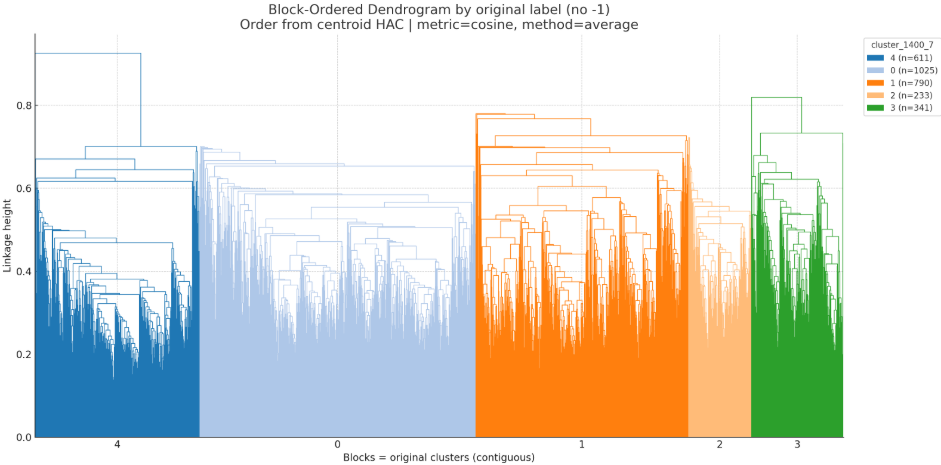

## 해석

- 각 블록(색상)은 HDBSCAN 클러스터 하나에 해당하며, 내부의 덴드로그램 높이가 낮을수록 해당 클러스터 내 리뷰들이 서로 유사함을 의미
- 블록 간 배치 순서는 centroid 간 HAC로 결정되어, 가까운 블록일수록 클러스터 간 의미가 유사
- metric=cosine, method=average로 UMAP+HDBSCAN 설정과 일관성을 유지